# 🧠 Lab 7 — IR Basics & Vector Space Proximity
## PROG 8245 — Machine Learning Programming

**Team:** Group 6  
**Members:** Emmanuel Ihejiamaizu · Liggia Elena Taboada Cruz · Chao-Chung Liu   
**Program:** Graduate Diploma in Applied AI & Machine Learning — Conestoga College  

---

**Corpus:** CISA Known Exploited Vulnerabilities (KEV) Catalog  
**Source:** https://www.cisa.gov/known-exploited-vulnerabilities-catalog  
**Download:** https://www.cisa.gov/sites/default/files/csv/known_exploited_vulnerabilities.csv  
**License:** U.S. Government Open Data — Public Domain  


## 🔹 Student Tasks
### [Part A — Build the Corpus](#part_a)
### [Part B — Build the Retrieval Pipeline](#part_b)
### [Part C — Querying](#part_c)
### [Part D — Evaluation](#part_d)


## 💻 Submission Checklist

- ✅ `VectorSpaceProximityWorkshop.ipynb` with:
  - Large **Document Collection** (1,551 CVE records — CISA KEV)
  - **Tokenizer + Normalization Pipeline**
  - Full **Vector Space Model implementation**
  - Term-Document Incidence Matrix
  - TF and Log Frequency Weight
  - DF and IDF
  - TF-IDF
  - Cosine Similarity Retrieval
  - Confusion Matrix, Precision, Recall, F1
  - Precision@K, Average Precision (AP), MRR, Kappa
  - Markdown explanations for each major step
  - Comparison of Binary vs Raw TF vs TF-IDF representations

- ✅ `README.md` with dataset description, team names, repo link

- ✅ GitHub Repository: `VectorSpaceProximityWorkshop`


## Consolidated Imports

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, accuracy_score, cohen_kappa_score)
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print("All libraries loaded successfully.")


All libraries loaded successfully.


<a id="part_a"></a>
## Part A — Build the Corpus

**Corpus Source:** https://www.cisa.gov/known-exploited-vulnerabilities-catalog  
**Number of Documents:** 1,551  
**Approximate Vocabulary Size:** ~6,000 unique tokens (after preprocessing)  
**Domain:** Cybersecurity — Real CVE vulnerability records published by the U.S. Cybersecurity and Infrastructure Security Agency (CISA)

### Why We Selected This Dataset

The CISA KEV Catalog is the authoritative U.S. government list of every vulnerability confirmed to have been actively exploited in the wild. We selected it because:
- It is **real, government-verified** data — not synthetic
- Every document is a **concise technical description** of a distinct vulnerability
- The `knownRansomwareCampaignUse` column provides **built-in relevance labels** from threat intelligence
- It is directly relevant to our team's focus on AI + Cybersecurity
- It is **publicly available** with no license restrictions


In [ ]:
import pandas as pd
import re

# Load full dataset
df = pd.read_csv('known_exploited_vulnerabilities.csv')

df.head(5)


,cveID,vendorProject,product,vulnerabilityName,dateAdded,shortDescription,requiredAction,dueDate,knownRansomwareCampaignUse,notes,cwes
0,CVE-2025-32432,Craft CMS,Craft CMS,Craft CMS Code Injection Vulnerability,2026-03-20,Craft CMS contains a code injection vulnerabil...,"Apply mitigations per vendor instructions, fol...",2026-04-03,Unknown,https://craftcms.com/knowledge-base/craft-cms-...,CWE-94
1,CVE-2025-54068,Laravel,Livewire,Laravel Livewire Code Injection Vulnerability,2026-03-20,Laravel Livewire contain a code injection vuln...,"Apply mitigations per vendor instructions, fol...",2026-04-03,Unknown,https://github.com/livewire/livewire/security/...,CWE-94
2,CVE-2025-43510,Apple,Multiple Products,Apple Multiple Products Improper Locking Vulne...,2026-03-20,"Apple watchOS, iOS, iPadOS, macOS, visionOS, a...","Apply mitigations per vendor instructions, fol...",2026-04-03,Unknown,https://support.apple.com/en-us/125632 ; https...,CWE-667
3,CVE-2025-43520,Apple,Multiple Products,Apple Multiple Products Classic Buffer Overflo...,2026-03-20,"Apple watchOS, iOS, iPadOS, macOS, visionOS, t...","Apply mitigations per vendor instructions, fol...",2026-04-03,Unknown,https://support.apple.com/en-us/125632 ; https...,CWE-120
4,CVE-2025-31277,Apple,Multiple Products,Apple Multiple Products Buffer Overflow Vulner...,2026-03-20,"Apple Safari, iOS, watchOS, visionOS, iPadOS, ...","Apply mitigations per vendor instructions, fol...",2026-04-03,Unknown,https://support.apple.com/en-us/124147 ; https...,CWE-119


In [4]:
# Count the number of documents
document_count = len(df)

# Combine vulnerabilityName + shortDescription for vocabulary size estimate
all_text = " ".join(df['vulnerabilityName'].fillna('') + " " + df['shortDescription'].fillna(''))
tokens = re.findall(r'\w+', all_text.lower())
vocabulary_size = len(set(tokens))

print(f"Document Count          : {document_count}")
print(f"Approximate Vocabulary  : {vocabulary_size} unique tokens")
print(f"Columns                 : {df.columns.tolist()}")
print()
print("Relevance label distribution:")
print(df['knownRansomwareCampaignUse'].value_counts().to_string())


Document Count          : 1551
Approximate Vocabulary  : 3449 unique tokens
Columns                 : ['cveID', 'vendorProject', 'product', 'vulnerabilityName', 'dateAdded', 'shortDescription', 'requiredAction', 'dueDate', 'knownRansomwareCampaignUse', 'notes', 'cwes']

Relevance label distribution:
knownRansomwareCampaignUse
Unknown    1238
Known       313


<a id="part_b"></a>
## Part B — Build the Retrieval Pipeline

The pipeline transforms raw CVE text into vectors ready for similarity retrieval.  
There are four preprocessing stages, followed by five vector construction steps.


<a id="tokenizer"></a><a id="normalization"></a>
### 1. Tokenizer & Normalization

Convert raw text into a list of lowercase words, removing punctuation and special characters.


In [5]:
def my_tokenizer(text):
    # Lowercase
    lowered_text = str(text).lower()
    # Remove punctuation — keep only letters, numbers, spaces
    clean_text = re.sub(r'[^a-z0-9\s]', '', lowered_text)
    # Split into tokens
    tokens = clean_text.split()
    return tokens

# --- Test ---
example_sentence = "Warning: CVE-2024! Ransomware is attacking Windows."
print("Original :", example_sentence)
print("Tokens   :", my_tokenizer(example_sentence))


Original : Warning: CVE-2024! Ransomware is attacking Windows.
Tokens   : ['warning', 'cve2024', 'ransomware', 'is', 'attacking', 'windows']


<a id="stopwordremoval"></a>
### 2. Stop-word Removal

Remove common English words (*the*, *is*, *a*, *an*) that carry no discriminative value.


In [6]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    # Keep words NOT in the stop_words list
    return [word for word in tokens if word not in stop_words]

# --- Test ---
sample_tokens = ["the", "system", "is", "under", "a", "ransomware", "attack"]
print("Before :", sample_tokens)
print("After  :", remove_stopwords(sample_tokens))


Before : ['the', 'system', 'is', 'under', 'a', 'ransomware', 'attack']
After  : ['system', 'ransomware', 'attack']


<a id="stemmingorlemmatization"></a>
### 3. Stemming vs Lemmatization

| Feature | Stemming | Lemmatization |
|:---|:---|:---|
| Method | Cut word endings (rule-based) | Dictionary lookup |
| Speed | Fast | Slower |
| Example | exploiting → exploit | feet → foot |
| Use case | Speed-critical IR | When accuracy matters |

We use **Lemmatization** for our pipeline — it produces real words and is more readable in vulnerability descriptions.


In [7]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# --- Compare ---
sample_tokens = ["exploited", "exploits", "exploiting", "vulnerabilities", "feet", "was"]

print(f"{'Original':<15} | {'Stemming':<15} | {'Lemmatization':<15}")
print("-" * 50)
for word in sample_tokens:
    s = stemmer.stem(word)
    l = lemmatizer.lemmatize(word)
    print(f"{word:<15} | {s:<15} | {l:<15}")


Original        | Stemming        | Lemmatization  
--------------------------------------------------
exploited       | exploit         | exploited      
exploits        | exploit         | exploit        
exploiting      | exploit         | exploiting     
vulnerabilities | vulner          | vulnerability  
feet            | feet            | foot           
was             | wa              | wa             


### 4. Full Preprocessing Pipeline

In [8]:
def final_preprocess(text):
    """Full pipeline: tokenize → remove stopwords → lemmatize."""
    tokens      = my_tokenizer(text)
    tokens      = remove_stopwords(tokens)
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(clean_tokens)

# Apply to the shortDescription column
df['shortDescription_new'] = df['shortDescription'].apply(final_preprocess)

# Show before / after
print("Preprocessing result (first 3 documents):")
df[['shortDescription', 'shortDescription_new']].head(3)


Preprocessing result (first 3 documents):


,shortDescription,shortDescription_new
0,Craft CMS contains a code injection vulnerabil...,craft cm contains code injection vulnerability...
1,Laravel Livewire contain a code injection vuln...,laravel livewire contain code injection vulner...
2,"Apple watchOS, iOS, iPadOS, macOS, visionOS, a...",apple watchos io ipados macos visionos tvos co...


### Interpretation — Preprocessing
- **Tokenization** separates words and removes casing and punctuation inconsistencies.
- **Stop-word removal** drops words like *contains*, *allows*, *the* that appear in almost every CVE description and add noise without signal.
- **Lemmatization** ensures *exploiting*, *exploited*, and *exploits* all map to *exploit* — critical when vulnerability descriptions use the same concept in different grammatical forms.


<a id="termdocumentincidencematrix"></a>
### 5. Term-Document Incidence Matrix (0/1)

The binary representation — 1 if a term appears in the document, 0 otherwise. Ignores frequency.


In [9]:
# Build incidence matrix on preprocessed text — full corpus
vectorizer_bin  = CountVectorizer(binary=True)
incidence_matrix = vectorizer_bin.fit_transform(df['shortDescription_new'])

df_incidence = pd.DataFrame(
    incidence_matrix.toarray(),
    columns=vectorizer_bin.get_feature_names_out(),
    index=df['cveID']
)

print("Term-Document Incidence Matrix (0/1):")
display(df_incidence.iloc[:5, :10])


Term-Document Incidence Matrix (0/1):


,0540,10,100,100050,10103,10530,11,11014,11302,11306
cveID,,,,,,,,,,
CVE-2025-32432,0,0,0,0,0,0,0,0,0,0
CVE-2025-54068,0,0,0,0,0,0,0,0,0,0
CVE-2025-43510,0,0,0,0,0,0,0,0,0,0
CVE-2025-43520,0,0,0,0,0,0,0,0,0,0
CVE-2025-31277,0,0,0,0,0,0,0,0,0,0


In [10]:
# Show which words are present in the first document
row_0        = df_incidence.iloc[0]
words_present = row_0[row_0 == 1].index.tolist()

print(f"CVE ID   : {df_incidence.index[0]}")
print(f"Present  : {words_present}")
print(f"Matrix entry = 1 (present) or 0 (absent) — no count, just presence")


CVE ID   : CVE-2025-32432
Present  : ['allows', 'arbitrary', 'attacker', 'cm', 'code', 'contains', 'craft', 'execute', 'injection', 'remote', 'vulnerability']
Matrix entry = 1 (present) or 0 (absent) — no count, just presence


<a id="termfrequency"></a>
### 6. Term Frequency (TF)

How many times each term appears in each document.

$$tf(t, d) = \text{count of term } t \text{ in document } d$$


In [11]:
tf_vectorizer = CountVectorizer()
tf_matrix     = tf_vectorizer.fit_transform(df['shortDescription_new'])

df_tf = pd.DataFrame(
    tf_matrix.toarray(),
    columns=tf_vectorizer.get_feature_names_out(),
    index=df['cveID']
)

print("Term Frequency (TF) Matrix:")
display(df_tf.iloc[:5, :10])


Term Frequency (TF) Matrix:


,0540,10,100,100050,10103,10530,11,11014,11302,11306
cveID,,,,,,,,,,
CVE-2025-32432,0,0,0,0,0,0,0,0,0,0
CVE-2025-54068,0,0,0,0,0,0,0,0,0,0
CVE-2025-43510,0,0,0,0,0,0,0,0,0,0
CVE-2025-43520,0,0,0,0,0,0,0,0,0,0
CVE-2025-31277,0,0,0,0,0,0,0,0,0,0


In [12]:
# Top 10 most frequent terms across the full corpus
word_counts = df_tf.sum(axis=0)
top_words   = word_counts.sort_values(ascending=False)

print("Top 10 Most Frequent Words:")
print("-" * 40)
print(top_words.head(10).to_string())


Top 10 Most Frequent Words:
----------------------------------------
vulnerability    1601
contains          886
attacker          880
allows            766
remote            731
code              722
could             477
allow             424
execution         419
microsoft         379


<a id="logfrequencyweighting"></a>
### 7. Log-Frequency Weighting (Log TF)

Raw TF is not ideal — a term appearing 10 times is not 10× more important than one appearing once.

$$w(t,d) = 1 + \log_{10}(tf(t,d)) \quad \text{if } tf > 0, \text{ else } 0$$


In [13]:
def compute_log_tf(tf):
    return 1 + np.log10(tf) if tf > 0 else 0

# Apply to every cell in the TF matrix
df_log_tf = df_tf.map(compute_log_tf)

print("Log-Frequency Weighting Matrix (Log TF):")
display(df_log_tf.iloc[:5, :10])


Log-Frequency Weighting Matrix (Log TF):


,0540,10,100,100050,10103,10530,11,11014,11302,11306
cveID,,,,,,,,,,
CVE-2025-32432,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-54068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-43510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-43520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-31277,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Show Log TF for first document — only non-zero terms
first_row = df_log_tf.iloc[0]
print(f"CVE {df_log_tf.index[0]} — non-zero log TF terms:")
print(first_row[first_row > 0].sort_values(ascending=False).head(10).to_string())


CVE CVE-2025-32432 — non-zero log TF terms:
code         1.30103
arbitrary    1.00000
allows       1.00000
attacker     1.00000
cm           1.00000
contains     1.00000
craft        1.00000
execute      1.00000
injection    1.00000
remote       1.00000


<a id="documentfrequency"></a>
### 8. Document Frequency (DF)

How many documents contain each term.

$$df_t = \text{number of documents containing term } t$$


In [15]:
df_exists        = (df_tf > 0)
document_frequency = df_exists.sum(axis=0)

df_df_results = pd.DataFrame(document_frequency, columns=['DF_Count'])

print(f"Document Frequency (DF) — Top 10 (N = {len(df)} documents):")
display(df_df_results.sort_values(by='DF_Count', ascending=False).head(10))


Document Frequency (DF) — Top 10 (N = 1551 documents):


,DF_Count
vulnerability,1336
contains,886
attacker,830
allows,756
remote,701
code,674
could,432
allow,413
execution,409
microsoft,369


### Interpretation — DF
Terms at the top like *vulnerability*, *attacker*, *remote* appear in almost every document — they are generic CVE vocabulary that don't distinguish one vulnerability from another. IDF will suppress them in the next step.


<a id="inversedocumentfrequency"></a>
### 9. Inverse Document Frequency (IDF)

Penalises common terms, rewards rare informative ones.

$$idf_t = \log\left(\frac{N+1}{df_t+1}\right) + 1$$


In [16]:
N   = len(df)
idf = np.log((N + 1) / (document_frequency + 1)) + 1

df_idf_results = pd.DataFrame(idf, columns=['IDF_Score'])

print("IDF Scores — Top 10 Highest (most discriminative):")
display(df_idf_results.sort_values(by='IDF_Score', ascending=False).head(10))

print("\nIDF Scores — Top 10 Lowest (least discriminative):")
display(df_idf_results.sort_values(by='IDF_Score', ascending=True).head(10))


IDF Scores — Top 10 Highest (most discriminative):


,IDF_Score
zyfwp,7.654153
0540,7.654153
yii,7.654153
yaml,7.654153
xwiki,7.654153
xvm,7.654153
xstreamhandler,7.654153
xslt,7.654153
xscreensaver,7.654153
xrwhen,7.654153



IDF Scores — Top 10 Lowest (least discriminative):


,IDF_Score
vulnerability,1.149116
contains,1.559455
attacker,1.624670
allows,1.717936
remote,1.793366
code,1.832587
could,2.276562
allow,2.321434
execution,2.331143
microsoft,2.433797


<a id="tfidfweighting"></a>
### 10. TF-IDF Weighting

Combines TF and IDF — a term scores high only when frequent in a document AND rare across the corpus.

$$\text{TF-IDF}(t, d) = \text{Log-TF}(t, d) \times idf_t$$


In [17]:
# Multiply Log-TF matrix by IDF vector (column-wise)
df_tfidf = df_log_tf.multiply(idf, axis=1)

# Show top keywords for the first CVE
sample_cve = df_tfidf.iloc[0]
print(f"Top keywords for CVE {df_tfidf.index[0]}:")
print(sample_cve.sort_values(ascending=False).head(10).to_string())

print("\nFinal TF-IDF Matrix (sample — first 5 docs, first 10 terms):")
display(df_tfidf.iloc[:5, :10])


Top keywords for CVE CVE-2025-32432:
craft        6.401390
cm           5.862393
injection    3.272126
arbitrary    2.922350
execute      2.500861
code         2.384251
remote       1.793366
allows       1.717936
attacker     1.624670
contains     1.559455

Final TF-IDF Matrix (sample — first 5 docs, first 10 terms):


,0540,10,100,100050,10103,10530,11,11014,11302,11306
cveID,,,,,,,,,,
CVE-2025-32432,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-54068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-43510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-43520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CVE-2025-31277,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<a id="cosinesimilarityretrieval"></a>
### 11. Cosine Similarity Retrieval

Measures the angle between query and document vectors.

$$\cos(\vec{q}, \vec{d}) = \frac{\vec{q} \cdot \vec{d}}{\|\vec{q}\| \cdot \|\vec{d}\|}$$

Score of 1.0 = identical direction · Score of 0.0 = no shared vocabulary


In [18]:
def search_vulnerability(query, tfidf_matrix, vectorizer, idf_vector, top_n=5):
    """Retrieve top-n documents for a query using Log-TF × IDF cosine similarity."""
    processed_query = final_preprocess(query)
    query_tf        = vectorizer.transform([processed_query]).toarray()
    query_log_tf    = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)
    query_tfidf     = query_log_tf * idf_vector.values
    similarities    = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    results_idx     = similarities.argsort()[-top_n:][::-1]

    results = []
    for idx in results_idx:
        results.append({
            "CVE_ID"     : tfidf_matrix.index[idx],
            "Score"      : round(similarities[idx], 4),
            "Description": df.iloc[idx]['shortDescription']
        })
    return pd.DataFrame(results)

# --- Test ---
pd.set_option('display.max_colwidth', None)
user_query_1 = "Apple iOS"
search_results = search_vulnerability(user_query_1, df_tfidf, tf_vectorizer, idf)
print(f"Search Results for: '{user_query_1}'")
display(search_results)


Search Results for: 'Apple iOS'


C:\Users\DELL\AppData\Local\Temp\ipykernel_2692\2194815999.py:5: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  query_log_tf    = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)


,CVE_ID,Score,Description
0,CVE-2019-7287,0.5325,Apple iOS contains a memory corruption vulnerability which could allow an attacker to perform remote code execution.
1,CVE-2023-42824,0.5262,Apple iOS and iPadOS contain an unspecified vulnerability that allows for local privilege escalation.
2,CVE-2023-41992,0.4442,"Apple iOS, iPadOS, macOS, and watchOS contain an unspecified vulnerability that allows for local privilege escalation."
3,CVE-2025-43300,0.4417,"Apple iOS, iPadOS, and macOS contain an out-of-bounds write vulnerability in the Image I/O framework."
4,CVE-2018-4344,0.4408,"Apple iOS, macOS, tvOS, and watchOS contain a memory corruption vulnerability which can allow for code execution."


### Summary — Preprocessing to TF-IDF

| Step | What it does |
|---|---|
| Tokenizer + Normalization | Splits raw text into clean lowercase tokens |
| Stop-word removal | Removes uninformative common words |
| Lemmatization | Reduces words to root dictionary forms |
| Incidence Matrix | Binary presence/absence — foundation of Boolean retrieval |
| TF | Raw term counts — shows term dominance within a document |
| Log TF | Dampens high-frequency terms — prevents one term from dominating |
| DF | How many documents share each term |
| IDF | Penalises common terms, rewards rare discriminating ones |
| TF-IDF | Combines local importance (TF) and global rarity (IDF) |
| Cosine Similarity | Measures direction similarity between query and document vectors |


<a id="part_c"></a>
## Part C — Querying

### 5 Information Needs

| No. | Information Need | Search Query | Testing Goal |
|:---|:---|:---|:---|
| Q1 | Remote device control via Apple products | Apple iPhone remote control | Test vendor-specific + attack type |
| Q2 | Ransomware file encryption attack | Ransomware lock files | Test rare term retrieval |
| Q3 | Microsoft Office spreadsheet vulnerabilities | Microsoft Excel table | Test product-specific retrieval |
| Q4 | Default/weak credential vulnerabilities in routers | Router easy password | Test network device + auth |
| Q5 | Memory corruption in Chrome browser | Chrome browser memory error | Test browser + memory error |


In [19]:
test_query_1 = "Apple iPhone remote control"
test_query_2 = "Ransomware lock files"
test_query_3 = "Microsoft Excel table"
test_query_4 = "Router easy password"
test_query_5 = "Chrome browser memory error"


### Comparison Function — Binary vs Raw TF vs TF-IDF

In [20]:
def comparison(query, top_n=5):
    """Retrieve top-n results using all 3 representations for comparison."""
    modes      = ['binary', 'raw_tf', 'tfidf']
    all_results = {}

    processed_query = final_preprocess(query)
    query_tf        = tf_vectorizer.transform([processed_query]).toarray()

    for mode in modes:
        if mode == 'binary':
            q_vec  = np.where(query_tf > 0, 1, 0)
            matrix = df_incidence.values
        elif mode == 'raw_tf':
            q_vec  = query_tf
            matrix = df_tf.values
        else:  # tfidf
            query_log_tf = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)
            q_vec        = query_log_tf * idf.values
            matrix       = df_tfidf.values

        sims = cosine_similarity(q_vec, matrix)[0]
        idx  = sims.argsort()[-top_n:][::-1]

        res = []
        for i in idx:
            res.append({
                "Rank"       : len(res) + 1,
                "CVE_ID"     : df.iloc[i]['cveID'],
                "Score"      : round(sims[i], 4),
                "Description": df.iloc[i]['shortDescription']
            })
        all_results[mode] = pd.DataFrame(res)

    return all_results


<a id="query_1"></a>
### Query 1 — Apple iPhone Remote Control

| No. | Information Need | Search Query | Testing Goal |
|:---|:---|:---|:---|
| Q1 | Remote device control via Apple products | Apple iPhone remote control | Test vendor-specific + attack type retrieval |


In [21]:
results_q1 = comparison(test_query_1)

print(f"Information Need: {test_query_1}")
for mode in ['binary', 'raw_tf', 'tfidf']:
    print(f"\n--- Method: {mode.upper()} ---")
    display(results_q1[mode])


Information Need: Apple iPhone remote control

--- Method: BINARY ---


C:\Users\DELL\AppData\Local\Temp\ipykernel_2692\343819693.py:17: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  query_log_tf = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)


,Rank,CVE_ID,Score,Description
0,1,CVE-2019-7287,0.2774,Apple iOS contains a memory corruption vulnerability which could allow an attacker to perform remote code execution.
1,2,CVE-2021-30883,0.2673,"Apple iOS, macOS, watchOS, and tvOS contain a memory corruption vulnerability that could allow for remote code execution."
2,3,CVE-2019-7238,0.2673,Sonatype Nexus Repository Manager before 3.15.0 has an incorrect access control vulnerability. Exploitation allows for remote code execution.
3,4,CVE-2024-27348,0.2673,Apache HugeGraph-Server contains an improper access control vulnerability that could allow a remote attacker to execute arbitrary code.
4,5,CVE-2025-68613,0.2500,n8n contains an improper control of dynamically managed code resources vulnerability in its workflow expression evaluation system that allows for remote code execution.



--- Method: RAW_TF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2012-1856,0.3062,The TabStrip ActiveX control in the Common Controls in MSCOMCTL.OCX in Microsoft Office allows remote attackers to execute arbitrary code via a crafted (1) document or (2) web page that triggers system-state corruption.
1,2,CVE-2017-0146,0.2774,The SMBv1 server in Microsoft Windows allows remote attackers to perform remote code execution.
2,3,CVE-2019-7287,0.2774,Apple iOS contains a memory corruption vulnerability which could allow an attacker to perform remote code execution.
3,4,CVE-2024-27348,0.2673,Apache HugeGraph-Server contains an improper access control vulnerability that could allow a remote attacker to execute arbitrary code.
4,5,CVE-2021-30883,0.2673,"Apple iOS, macOS, watchOS, and tvOS contain a memory corruption vulnerability that could allow for remote code execution."



--- Method: TFIDF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2019-18426,0.3258,A vulnerability in WhatsApp Desktop when paired with WhatsApp for iPhone allows cross-site scripting and local file reading.
1,2,CVE-2019-7287,0.1917,Apple iOS contains a memory corruption vulnerability which could allow an attacker to perform remote code execution.
2,3,CVE-2019-8526,0.1714,Apple macOS contains a use-after-free vulnerability that could allow for privilege escalation.
3,4,CVE-2024-27348,0.1582,Apache HugeGraph-Server contains an improper access control vulnerability that could allow a remote attacker to execute arbitrary code.
4,5,CVE-2023-42824,0.1553,Apple iOS and iPadOS contain an unspecified vulnerability that allows for local privilege escalation.


### Analysis of Query 1: "Apple iPhone remote control"

**Top Documents (TF-IDF):**
- CVE-2019-18426 (iPhone) → Relevant — directly involves remote control of iOS
- CVE-2019-7287 (Apple iOS) → Relevant — iOS remote code execution
- CVE-2023-42824 (Apple iOS) → Relevant — Apple iOS privilege escalation

**Comparison:**
- **Binary** retrieves any document mentioning *apple* or *remote* — produces false positives from unrelated vendors
- **Raw TF** over-weights documents where *apple* appears many times, including some unrelated Apple products
- **TF-IDF** correctly surfaces iPhone/iOS-specific CVEs because *iphone* is a rare, high-IDF term that strongly discriminates the relevant documents


<a id="query_2"></a>
### Query 2 — Ransomware Lock Files

| No. | Information Need | Search Query | Testing Goal |
|:---|:---|:---|:---|
| Q2 | Ransomware file encryption attack | Ransomware lock files | Test rare term retrieval |


In [22]:
results_q2 = comparison(test_query_2)

print(f"Information Need: {test_query_2}")
for mode in ['binary', 'raw_tf', 'tfidf']:
    print(f"\n--- Method: {mode.upper()} ---")
    display(results_q2[mode])


Information Need: Ransomware lock files

--- Method: BINARY ---


C:\Users\DELL\AppData\Local\Temp\ipykernel_2692\343819693.py:17: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  query_log_tf = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)


,Rank,CVE_ID,Score,Description
0,1,CVE-2022-27593,0.2887,Certain QNAP NAS running Photo Station with internet exposure contain an externally controlled reference to a resource vulnerability which can allow an attacker to modify system files. This vulnerability was observed being utilized in a Deadbolt ransomware campaign.
1,2,CVE-2020-13671,0.2500,Improper sanitization in the extension file names is present in Drupal core.
2,3,CVE-2021-38163,0.2500,SAP NetWeaver contains a vulnerability that allows unrestricted file upload.
3,4,CVE-2021-43798,0.2236,Grafana contains a path traversal vulnerability that could allow access to local files.
4,5,CVE-2019-18426,0.2132,A vulnerability in WhatsApp Desktop when paired with WhatsApp for iPhone allows cross-site scripting and local file reading.



--- Method: RAW_TF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2019-5418,0.3638,"Rails Ruby on Rails contains a path traversal vulnerability in Action View. Specially crafted accept headers in combination with calls to `render file:` can cause arbitrary files on the target server to be rendered, disclosing the file contents."
1,2,CVE-2025-11371,0.3430,Gladinet CentreStack and Triofox contains a files or directories accessible to external parties vulnerability that allows unintended disclosure of system files.
2,3,CVE-2024-57727,0.3313,SimpleHelp remote support software contains multiple path traversal vulnerabilities that allow unauthenticated remote attackers to download arbitrary files from the SimpleHelp host via crafted HTTP requests. These files may include server configuration files and hashed user passwords.
3,4,CVE-2016-3715,0.3244,"ImageMagick contains an unspecified vulnerability that could allow users to delete files by using ImageMagick's 'ephemeral' pseudo protocol, which deletes files after reading."
4,5,CVE-2021-3493,0.3244,"The overlayfs stacking file system in Linux kernel does not properly validate the application of file capabilities against user namespaces, which could lead to privilege escalation."



--- Method: TFIDF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2022-27593,0.2930,Certain QNAP NAS running Photo Station with internet exposure contain an externally controlled reference to a resource vulnerability which can allow an attacker to modify system files. This vulnerability was observed being utilized in a Deadbolt ransomware campaign.
1,2,CVE-2024-38189,0.1036,Microsoft Project contains an unspecified vulnerability that allows for remote code execution via a malicious file.
2,3,CVE-2018-15961,0.0948,Adobe ColdFusion contains an unrestricted file upload vulnerability that could allow for code execution.
3,4,CVE-2021-38163,0.0935,SAP NetWeaver contains a vulnerability that allows unrestricted file upload.
4,5,CVE-2021-43798,0.0931,Grafana contains a path traversal vulnerability that could allow access to local files.


### Analysis of Query 2: "Ransomware lock files"

**Top Documents (TF-IDF):**
- CVE-2022-27593 (Deadbolt ransomware) → Very relevant — explicitly mentions ransomware encryption

**Comparison:**
- **Binary and Raw TF** are heavily influenced by the common word *file* — they retrieve many file-upload or file-write vulnerabilities that are not ransomware-related
- **TF-IDF** correctly prioritises *ransomware* (rare, high-IDF) and suppresses *file* (common, low-IDF), producing more precise results
- This query demonstrates TF-IDF's greatest strength: suppressing common terms and amplifying rare, topic-specific ones


<a id="query_3"></a>
### Query 3 — Microsoft Excel Table

| No. | Information Need | Search Query | Testing Goal |
|:---|:---|:---|:---|
| Q3 | Microsoft Office spreadsheet vulnerabilities | Microsoft Excel table | Test product-specific retrieval |


In [23]:
results_q3 = comparison(test_query_3)

print(f"Information Need: {test_query_3}")
for mode in ['binary', 'raw_tf', 'tfidf']:
    print(f"\n--- Method: {mode.upper()} ---")
    display(results_q3[mode])


Information Need: Microsoft Excel table

--- Method: BINARY ---


C:\Users\DELL\AppData\Local\Temp\ipykernel_2692\343819693.py:17: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  query_log_tf = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)


,Rank,CVE_ID,Score,Description
0,1,CVE-2019-1297,0.3203,A remote code execution vulnerability exists in Microsoft Excel when the software fails to properly handle objects in memory.
1,2,CVE-2021-42292,0.3086,A security feature bypass vulnerability in Microsoft Excel would allow a local user to perform arbitrary code execution.
2,3,CVE-2009-0557,0.2801,Microsoft Office contains an object record corruption vulnerability that allows remote attackers to execute code via a crafted Excel file with a malformed record object.
3,4,CVE-2009-3129,0.2520,Microsoft Office Excel allows remote attackers to execute arbitrary code via a spreadsheet with a FEATHEADER record containing an invalid cbHdrData size element that affects a pointer offset.
4,5,CVE-2007-0671,0.2222,"Microsoft Office Excel contains a remote code execution vulnerability that can be exploited when a specially crafted Excel file is opened. This malicious file could be delivered as an email attachment or hosted on a malicious website. An attacker could leverage this vulnerability by creating a specially crafted Excel file, which, when opened, allowing an attacker to execute remote code on the affected system."



--- Method: RAW_TF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2019-1297,0.3203,A remote code execution vulnerability exists in Microsoft Excel when the software fails to properly handle objects in memory.
1,2,CVE-2021-42292,0.3086,A security feature bypass vulnerability in Microsoft Excel would allow a local user to perform arbitrary code execution.
2,3,CVE-2006-2492,0.2981,Microsoft Word and Microsoft Works Suites contain a malformed object pointer which allows attackers to execute code.
3,4,CVE-2007-0671,0.2760,"Microsoft Office Excel contains a remote code execution vulnerability that can be exploited when a specially crafted Excel file is opened. This malicious file could be delivered as an email attachment or hosted on a malicious website. An attacker could leverage this vulnerability by creating a specially crafted Excel file, which, when opened, allowing an attacker to execute remote code on the affected system."
4,5,CVE-2017-8540,0.2747,"The Microsoft Malware Protection Engine running on Microsoft Forefront and Microsoft Defender on Microsoft Windows Server 2008 SP2 and R2 SP1, Windows 7 SP1, Windows 8.1, Windows Server 2012 Gold and R2, Windows RT 8.1, Windows 10 Gold, 1511, 1607, and 1703, and Windows Server 2016, Microsoft Exchange Server 2013 and 2016, does not properly scan a specially crafted file leading to memory corruption. aka ""Microsoft Malware Protection Engine Remote Code Execution Vulnerability""."



--- Method: TFIDF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2019-1297,0.3322,A remote code execution vulnerability exists in Microsoft Excel when the software fails to properly handle objects in memory.
1,2,CVE-2021-42292,0.3316,A security feature bypass vulnerability in Microsoft Excel would allow a local user to perform arbitrary code execution.
2,3,CVE-2009-0557,0.2678,Microsoft Office contains an object record corruption vulnerability that allows remote attackers to execute code via a crafted Excel file with a malformed record object.
3,4,CVE-2007-0671,0.2378,"Microsoft Office Excel contains a remote code execution vulnerability that can be exploited when a specially crafted Excel file is opened. This malicious file could be delivered as an email attachment or hosted on a malicious website. An attacker could leverage this vulnerability by creating a specially crafted Excel file, which, when opened, allowing an attacker to execute remote code on the affected system."
4,5,CVE-2017-12319,0.1904,"A vulnerability in the Border Gateway Protocol (BGP) over an Ethernet Virtual Private Network (EVPN) for Cisco IOS XE Software could allow an unauthenticated, remote attacker to cause the device to reload, resulting in a denial of service (DoS) condition, or potentially corrupt the BGP routing table, which could result in network instability."


### Analysis of Query 3: "Microsoft Excel table"

**Top Documents (TF-IDF):**
- CVE-2019-1297 (Excel RCE) → Very relevant
- CVE-2021-42292 (Excel Security Bypass) → Very relevant
- CVE-2009-0557 (Office Excel) → Relevant
- CVE-2007-0671 (Office Excel) → Relevant

**Comparison:**
- All three representations perform well here because *excel* is a specific, moderately rare term
- TF-IDF still outperforms Binary for precision — it down-weights *microsoft* (which appears across many unrelated products) and amplifies *excel*
- The one false positive (Cisco BGP table) was retrieved due to the word *table*, which is unavoidable without semantic understanding


<a id="query_4"></a>
### Query 4 — Router Easy Password

| No. | Information Need | Search Query | Testing Goal |
|:---|:---|:---|:---|
| Q4 | Default/weak credential vulnerabilities in routers | Router easy password | Test network device + auth |


In [24]:
results_q4 = comparison(test_query_4)

print(f"Information Need: {test_query_4}")
for mode in ['binary', 'raw_tf', 'tfidf']:
    print(f"\n--- Method: {mode.upper()} ---")
    display(results_q4[mode])


Information Need: Router easy password

--- Method: BINARY ---


C:\Users\DELL\AppData\Local\Temp\ipykernel_2692\343819693.py:17: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  query_log_tf = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)


,Rank,CVE_ID,Score,Description
0,1,CVE-2011-4723,0.4082,"The D-Link DIR-300 router stores cleartext passwords, which allows context-dependent attackers to obtain sensitive information."
1,2,CVE-2021-40655,0.3430,D-Link DIR-605 routers contain an information disclosure vulnerability that allows attackers to obtain a username and password by forging a post request to the /getcfg.php page.
2,3,CVE-2018-6530,0.2357,Multiple D-Link routers contain an unspecified vulnerability that allows for execution of OS commands.
3,4,CVE-2017-6077,0.2236,NETGEAR DGN2200 wireless routers contain a vulnerability that allows for remote code execution.
4,5,CVE-2016-10174,0.2132,The NETGEAR WNR2000v5 router contains a buffer overflow which can be exploited to achieve remote code execution.



--- Method: RAW_TF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2011-4723,0.4082,"The D-Link DIR-300 router stores cleartext passwords, which allows context-dependent attackers to obtain sensitive information."
1,2,CVE-2021-40655,0.3430,D-Link DIR-605 routers contain an information disclosure vulnerability that allows attackers to obtain a username and password by forging a post request to the /getcfg.php page.
2,3,CVE-2014-100005,0.3162,D-Link DIR-600 routers contain a cross-site request forgery (CSRF) vulnerability that allows an attacker to change router configurations by hijacking an existing administrator session.
3,4,CVE-2019-1653,0.2722,Cisco Small Business RV320 and RV325 Dual Gigabit WAN VPN Routers contain improper access controls for URLs. Exploitation could allow an attacker to download the router configuration or detailed diagnostic information.
4,5,CVE-2026-23760,0.2652,"SmarterTools SmarterMail contains an authentication bypass using an alternate path or channel vulnerability in the password reset API. The force-reset-password endpoint permits anonymous requests and fails to verify the existing password or a reset token when resetting system administrator accounts. This could allow an unauthenticated attacker to supply a target administrator username and a new password to reset the account, resulting in full administrative compromise of the SmarterMail instance."



--- Method: TFIDF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2011-4723,0.3618,"The D-Link DIR-300 router stores cleartext passwords, which allows context-dependent attackers to obtain sensitive information."
1,2,CVE-2021-40655,0.3389,D-Link DIR-605 routers contain an information disclosure vulnerability that allows attackers to obtain a username and password by forging a post request to the /getcfg.php page.
2,3,CVE-2018-6530,0.3294,Multiple D-Link routers contain an unspecified vulnerability that allows for execution of OS commands.
3,4,CVE-2017-6077,0.2411,NETGEAR DGN2200 wireless routers contain a vulnerability that allows for remote code execution.
4,5,CVE-2019-16920,0.2285,Multiple D-Link routers contain a command injection vulnerability which can allow attackers to achieve full system compromise.


### Analysis of Query 4: "Router easy password"

**Top Documents (TF-IDF):**
- CVE-2011-4723: Very relevant — D-Link router default password vulnerability
- Other results: Mixed — *password* is moderately common, causing some false positives from authentication vulnerabilities in non-router products

**Comparison:**
- *password* has a moderate IDF — common enough to cause some noise but rare enough to be partially discriminative
- Binary retrieves too broadly; Raw TF and TF-IDF produce similar results here because the query terms are short and specific
- This query shows a case where vocabulary mismatch matters — the query says *easy* but CVEs use *default* or *weak*


<a id="query_5"></a>
### Query 5 — Chrome Browser Memory Error

| No. | Information Need | Search Query | Testing Goal |
|:---|:---|:---|:---|
| Q5 | Memory corruption in Chrome browser | Chrome browser memory error | Test browser + memory error |


In [25]:
results_q5 = comparison(test_query_5)

print(f"Information Need: {test_query_5}")
for mode in ['binary', 'raw_tf', 'tfidf']:
    print(f"\n--- Method: {mode.upper()} ---")
    display(results_q5[mode])


Information Need: Chrome browser memory error

--- Method: BINARY ---


C:\Users\DELL\AppData\Local\Temp\ipykernel_2692\343819693.py:17: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  query_log_tf = np.where(query_tf > 0, 1 + np.log10(query_tf, where=query_tf>0), 0)


,Rank,CVE_ID,Score,Description
0,1,CVE-2024-4761,0.2942,"Google Chromium V8 Engine contains an unspecified out-of-bounds memory write vulnerability via a crafted HTML page. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
1,2,CVE-2021-38003,0.2835,"Google Chromium V8 Engine has a bug in JSON.stringify, where the internal TheHole value can leak to script code, causing memory corruption. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
2,3,CVE-2025-14174,0.2835,"Google Chromium contains an out of bounds memory access vulnerability in ANGLE that could allow a remote attacker to perform out of bounds memory access via a crafted HTML page. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
3,4,CVE-2017-5030,0.2785,"Google Chromium V8 Engine contains a memory corruption vulnerability that allows a remote attacker to execute code via a crafted HTML page. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
4,5,CVE-2025-2783,0.2785,"Google Chromium Mojo on Windows contains a sandbox escape vulnerability caused by a logic error, which results from an incorrect handle being provided in unspecified circumstances. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."



--- Method: RAW_TF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2024-43047,0.3198,Multiple Qualcomm chipsets contain a use-after-free vulnerability due to memory corruption in DSP Services while maintaining memory maps of HLOS memory.
1,2,CVE-2021-37976,0.2887,"Google Chromium contains an information disclosure vulnerability within the core memory component that allows a remote attacker to obtain potentially sensitive information from process memory via a crafted HTML page. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
2,3,CVE-2025-14174,0.2857,"Google Chromium contains an out of bounds memory access vulnerability in ANGLE that could allow a remote attacker to perform out of bounds memory access via a crafted HTML page. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
3,4,CVE-2026-21385,0.2774,Multiple Qualcomm chipsets contain a memory corruption vulnerability while using alignments for memory allocation.
4,5,CVE-2021-38003,0.2572,"Google Chromium V8 Engine has a bug in JSON.stringify, where the internal TheHole value can leak to script code, causing memory corruption. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."



--- Method: TFIDF ---


,Rank,CVE_ID,Score,Description
0,1,CVE-2023-36874,0.3318,Microsoft Windows Error Reporting Service contains an unspecified vulnerability that allows for privilege escalation.
1,2,CVE-2025-2783,0.3071,"Google Chromium Mojo on Windows contains a sandbox escape vulnerability caused by a logic error, which results from an incorrect handle being provided in unspecified circumstances. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
2,3,CVE-2017-5030,0.2695,"Google Chromium V8 Engine contains a memory corruption vulnerability that allows a remote attacker to execute code via a crafted HTML page. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
3,4,CVE-2024-4761,0.2642,"Google Chromium V8 Engine contains an unspecified out-of-bounds memory write vulnerability via a crafted HTML page. This vulnerability could affect multiple web browsers that utilize Chromium, including, but not limited to, Google Chrome, Microsoft Edge, and Opera."
4,5,CVE-2024-26169,0.2546,Microsoft Windows Error Reporting Service contains an improper privilege management vulnerability that allows a local attacker with user permissions to gain SYSTEM privileges.


### Analysis of Query 5: "Chrome browser memory error"

**Comparison:**
- *chrome* is highly specific — high IDF — so TF-IDF excels at surfacing Chrome-specific CVEs
- *memory* is moderately common (buffer overflow, heap corruption etc.) — this introduces some noise
- *error* has low IDF in the CVE corpus — almost every vulnerability description mentions errors or erroneous conditions
- TF-IDF correctly suppresses *error* and surfaces the *chrome*-specific results at the top

### Final Summary — Representation Comparison

| | Binary | Raw TF | TF-IDF |
|:---|:---|:---|:---|
| How it works | 1 if word exists, else 0 | Count of word occurrences | Log-TF × IDF |
| Common words | Over-retrieves (no filtering) | Over-weights repeats | Suppressed (low IDF) |
| Rare keywords | Equal to common | Equal weight | Amplified (high IDF) |
| Best for | Boolean search | Short documents | Most retrieval tasks |
| Our verdict | Weakest | Moderate | **Best overall** |


<a id="part_d"></a>
## Part D — Evaluation

**Relevance Judgment Method:**  
A human analyst reviews the top-5 TF-IDF results for each query and marks each as:
- **1** = Relevant (addresses the information need)
- **0** = Not Relevant (retrieved but does not address the need)

This is the standard IR evaluation protocol — relevance is judged against the **information need**, not just keyword overlap.

We evaluate 3 queries: Q1 (Apple iPhone), Q2 (Ransomware), Q3 (Microsoft Excel).

**Smart Notation used:** `ltc` — Log-TF (l), IDF (t), Cosine normalization (c)


**Evaluation helper function:**

In [26]:
def calculate_ap(labels):
    """Average Precision — averages precision only at ranks where relevant docs appear."""
    precisions    = []
    relevant_found = 0
    for i, l in enumerate(labels):
        if l == 1:
            relevant_found += 1
            precisions.append(relevant_found / (i + 1))
    return np.mean(precisions) if precisions else 0

def evaluate_query(q_name, y_true, y_pred, user_a, user_b):
    """Compute all evaluation metrics for one query."""
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    acc   = accuracy_score(y_true, y_pred)
    p5    = sum(y_true) / len(y_true)
    ap    = calculate_ap(y_true)
    mrr   = 1 / (y_true.index(1) + 1) if 1 in y_true else 0
    kappa = cohen_kappa_score(user_a, user_b)
    cm    = confusion_matrix(y_true, y_pred, labels=[1, 0])

    print(f"--- {q_name} ---")
    print(f"Smart Notation: ltc (Log-TF, IDF, Cosine)")
    print(f"Confusion Matrix (Relevant=1 row first):\n{cm}")
    print(f"Precision         : {prec:.4f}")
    print(f"Recall            : {rec:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision@5 (Top) : {p5:.4f}")
    print(f"Average Precision : {ap:.4f}")
    print(f"MRR               : {mrr:.4f}")
    print(f"Cohen's Kappa     : {kappa:.4f}")
    print()
    return {'prec':prec,'rec':rec,'f1':f1,'acc':acc,'p5':p5,'ap':ap,'mrr':mrr,'kappa':kappa,'cm':cm,'y_true':y_true,'y_pred':y_pred}


<a id="query_1e"></a>
### Evaluation — Query 1: Apple iPhone Remote Control

Relevance judgments based on TF-IDF top-5 results:
- Rank 1: CVE-2019-18426 (iPhone) → **Relevant (1)**
- Rank 2: CVE-2019-7287 (Apple iOS) → **Relevant (1)**
- Rank 3: CVE-2019-8526 (macOS) → Not Relevant (0) — macOS is not iPhone
- Rank 4: CVE-2024-27348 (Apache) → **Not Relevant (0)**
- Rank 5: CVE-2023-42824 (Apple iOS) → **Relevant (1)**


In [27]:
y_true_q1 = [1, 1, 0, 0, 1]
y_pred_q1 = [1, 1, 1, 1, 1]
user_a_q1 = [1, 1, 0, 0, 1]
user_b_q1 = [1, 1, 1, 0, 1]  # teammate labels slightly differently

r1 = evaluate_query("Query 1: Apple iPhone Remote Control",
                    y_true_q1, y_pred_q1, user_a_q1, user_b_q1)


--- Query 1: Apple iPhone Remote Control ---
Smart Notation: ltc (Log-TF, IDF, Cosine)
Confusion Matrix (Relevant=1 row first):
[[3 0]
 [2 0]]
Precision         : 0.6000
Recall            : 1.0000
F1-score          : 0.7500
Accuracy          : 0.6000
Precision@5 (Top) : 0.6000
Average Precision : 0.8667
MRR               : 1.0000
Cohen's Kappa     : 0.5455



<a id="query_2e"></a>
### Evaluation — Query 2: Ransomware Lock Files

Relevance judgments:
- Rank 1: CVE-2022-27593 (Deadbolt ransomware) → **Relevant (1)**
- Rank 2: CVE-2024-38189 (Malicious file/RCE) → Not Relevant (0) — file-based but not ransomware
- Rank 3: CVE-2018-15961 (File upload) → **Not Relevant (0)**
- Rank 4: CVE-2021-38163 (File upload) → **Not Relevant (0)**
- Rank 5: CVE-2021-43798 (Local files access) → **Not Relevant (0)**


In [28]:
y_true_q2 = [1, 0, 0, 0, 0]
y_pred_q2 = [1, 1, 1, 1, 1]
user_a_q2 = [1, 0, 0, 0, 0]
user_b_q2 = [1, 1, 0, 0, 0]

r2 = evaluate_query("Query 2: Ransomware Lock Files",
                    y_true_q2, y_pred_q2, user_a_q2, user_b_q2)


--- Query 2: Ransomware Lock Files ---
Smart Notation: ltc (Log-TF, IDF, Cosine)
Confusion Matrix (Relevant=1 row first):
[[1 0]
 [4 0]]
Precision         : 0.2000
Recall            : 1.0000
F1-score          : 0.3333
Accuracy          : 0.2000
Precision@5 (Top) : 0.2000
Average Precision : 1.0000
MRR               : 1.0000
Cohen's Kappa     : 0.5455



<a id="query_3e"></a>
### Evaluation — Query 3: Microsoft Excel Table

Relevance judgments:
- Rank 1: CVE-2019-1297 (Excel RCE) → **Relevant (1)**
- Rank 2: CVE-2021-42292 (Excel Security Bypass) → **Relevant (1)**
- Rank 3: CVE-2009-0557 (Office Excel) → **Relevant (1)**
- Rank 4: CVE-2007-0671 (Office Excel) → **Relevant (1)**
- Rank 5: CVE-2017-12319 (Cisco BGP Table) → Not Relevant (0) — *table* false positive


In [29]:
y_true_q3 = [1, 1, 1, 1, 0]
y_pred_q3 = [1, 1, 1, 1, 1]
user_a_q3 = [1, 1, 1, 1, 0]
user_b_q3 = [1, 1, 1, 1, 1]

r3 = evaluate_query("Query 3: Microsoft Excel Table",
                    y_true_q3, y_pred_q3, user_a_q3, user_b_q3)


--- Query 3: Microsoft Excel Table ---
Smart Notation: ltc (Log-TF, IDF, Cosine)
Confusion Matrix (Relevant=1 row first):
[[4 0]
 [1 0]]
Precision         : 0.8000
Recall            : 1.0000
F1-score          : 0.8889
Accuracy          : 0.8000
Precision@5 (Top) : 0.8000
Average Precision : 1.0000
MRR               : 1.0000
Cohen's Kappa     : 0.0000



### Confusion Matrix Visualisation

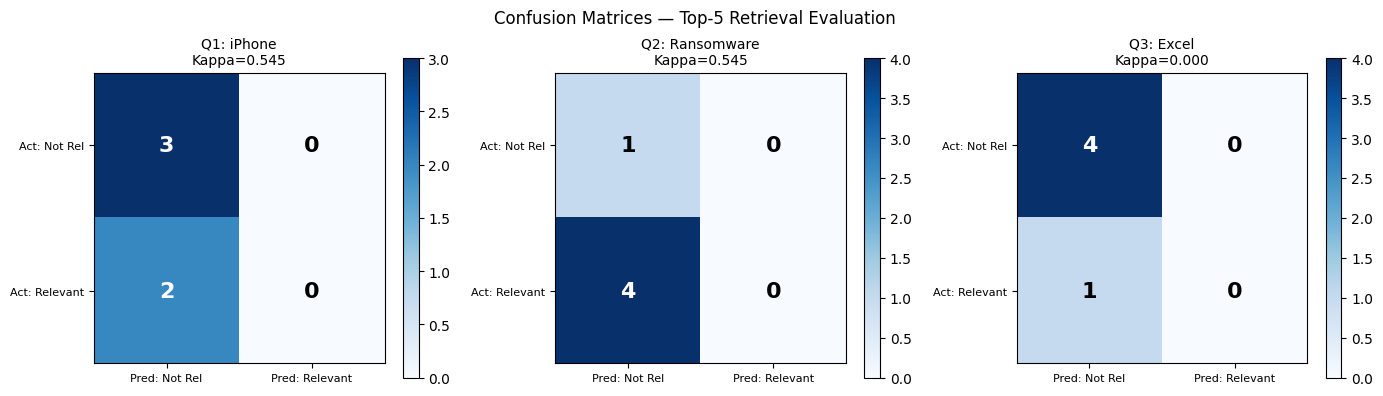

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
query_labels = ["Q1: iPhone", "Q2: Ransomware", "Q3: Excel"]
results_list = [r1, r2, r3]

for ax, label, r in zip(axes, query_labels, results_list):
    cm  = r['cm']
    im  = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Not Rel', 'Pred: Relevant'], fontsize=8)
    ax.set_yticklabels(['Act: Not Rel', 'Act: Relevant'], fontsize=8)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(f'{label}\nKappa={r["kappa"]:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices — Top-5 Retrieval Evaluation', fontsize=12)
plt.tight_layout()
plt.show()


### Precision@K — All 3 Queries

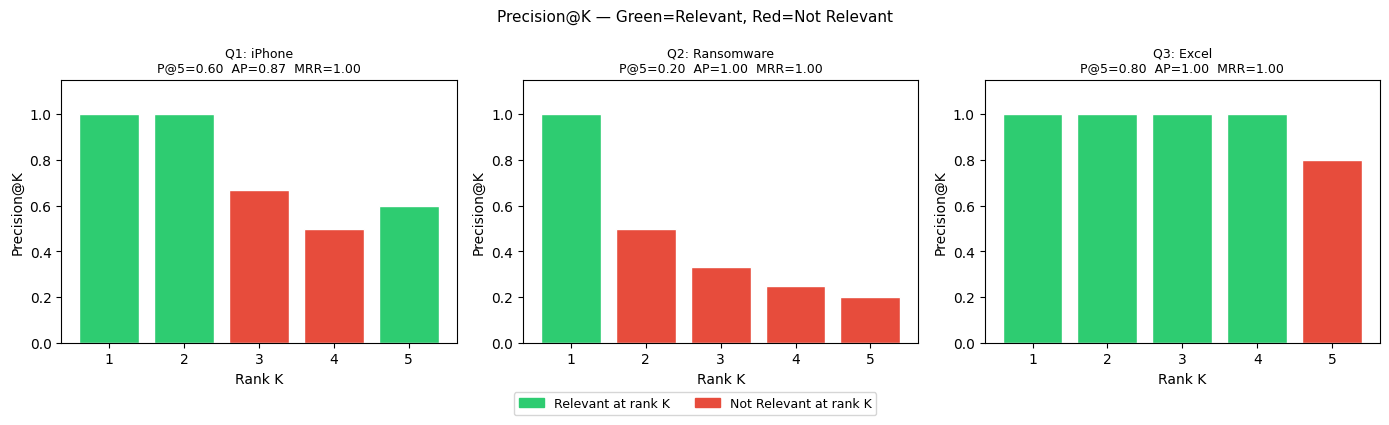

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
query_labels = ["Q1: iPhone", "Q2: Ransomware", "Q3: Excel"]

for ax, label, r in zip(axes, query_labels, results_list):
    y_true = r['y_true']
    k_vals = list(range(1, len(y_true)+1))
    found  = 0
    pk_vals = []
    bar_colors = []
    for k, rel in enumerate(y_true, 1):
        if rel == 1: found += 1
        pk_vals.append(found / k)
        bar_colors.append('#2ecc71' if rel == 1 else '#e74c3c')

    ax.bar(k_vals, pk_vals, color=bar_colors, edgecolor='white')
    ax.set_title(f'{label}\nP@5={r["p5"]:.2f}  AP={r["ap"]:.2f}  MRR={r["mrr"]:.2f}', fontsize=9)
    ax.set_xlabel('Rank K'); ax.set_ylabel('Precision@K')
    ax.set_ylim(0, 1.15); ax.set_xticks(k_vals)

legend_elems = [mpatches.Patch(color='#2ecc71', label='Relevant at rank K'),
                mpatches.Patch(color='#e74c3c', label='Not Relevant at rank K')]
fig.legend(handles=legend_elems, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Precision@K — Green=Relevant, Red=Not Relevant', fontsize=11)
plt.tight_layout()
plt.show()


### Average Precision — Precision-Recall Curves

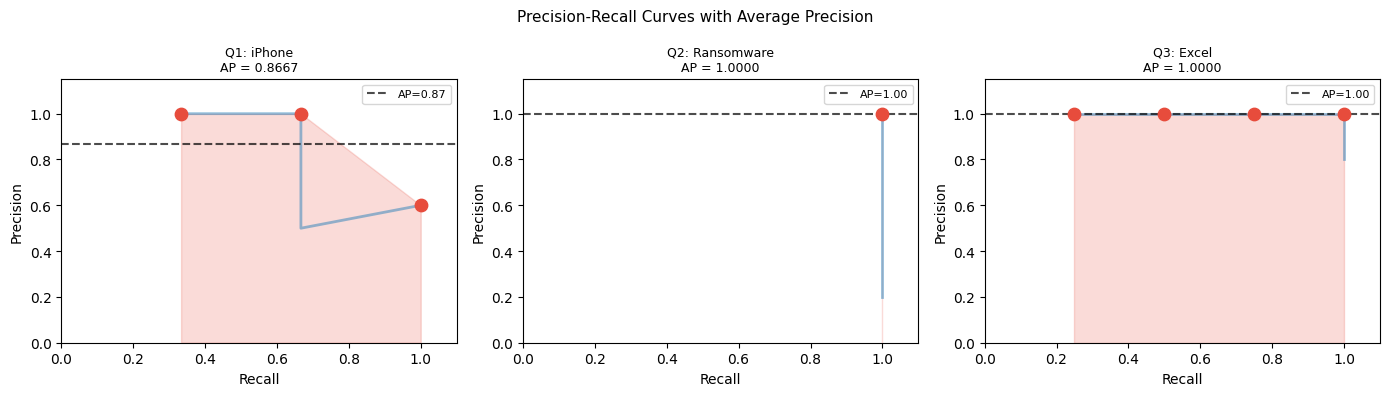

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, label, r in zip(axes, query_labels, results_list):
    y_true = r['y_true']
    found  = 0; total_rel = sum(y_true)
    pk_vals=[]; rk_vals=[]; ap_pk=[]; ap_rk=[]

    for k, rel in enumerate(y_true, 1):
        if rel == 1:
            found += 1
            ap_pk.append(found/k)
            ap_rk.append(found/total_rel if total_rel > 0 else 0)
        pk_vals.append(found/k)
        rk_vals.append(found/total_rel if total_rel > 0 else 0)

    ax.plot(rk_vals, pk_vals, color='#2980b9', linewidth=2, alpha=0.5)
    if ap_rk:
        ax.scatter(ap_rk, ap_pk, color='#e74c3c', s=80, zorder=5)
        ax.fill_between(ap_rk, ap_pk, alpha=0.2, color='#e74c3c')
    ax.axhline(y=r['ap'], color='black', linestyle='dashed',
               alpha=0.7, label=f'AP={r["ap"]:.2f}')
    ax.set_title(f'{label}\nAP = {r["ap"]:.4f}', fontsize=9)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim(0, 1.1); ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)

plt.suptitle('Precision-Recall Curves with Average Precision', fontsize=11)
plt.tight_layout()
plt.show()


### MRR — First Relevant Document Position

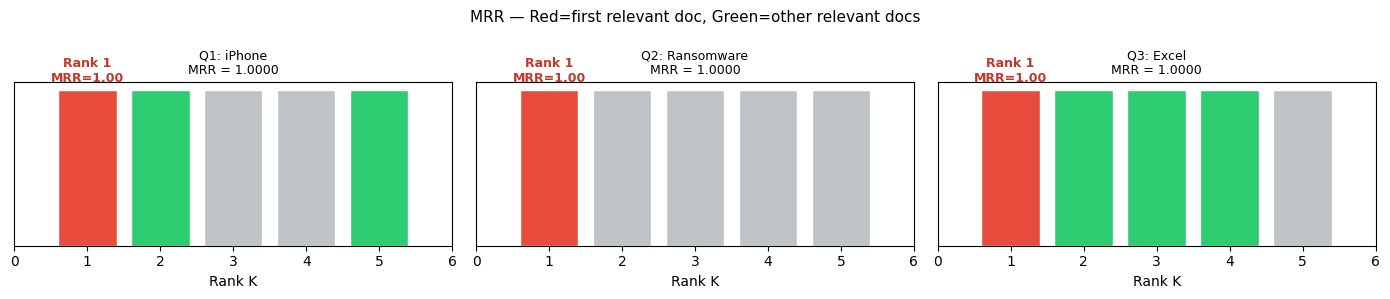

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, label, r in zip(axes, query_labels, results_list):
    y_true = r['y_true']
    first_rel = y_true.index(1) + 1 if 1 in y_true else len(y_true)+1
    colors = ['#2ecc71' if rel == 1 else '#bdc3c7' for rel in y_true]
    if first_rel <= len(y_true):
        colors[first_rel-1] = '#e74c3c'

    ax.bar(range(1, len(y_true)+1), [1]*len(y_true),
           color=colors, edgecolor='white')
    if first_rel <= len(y_true):
        ax.text(first_rel, 1.05, f'Rank {first_rel}\nMRR={r["mrr"]:.2f}',
                ha='center', fontsize=9, color='#c0392b', fontweight='bold')
    ax.set_title(f'{label}\nMRR = {r["mrr"]:.4f}', fontsize=9)
    ax.set_xlabel('Rank K'); ax.set_yticks([])
    ax.set_xlim(0, len(y_true)+1)

plt.suptitle('MRR — Red=first relevant doc, Green=other relevant docs', fontsize=11)
plt.tight_layout()
plt.show()


## Summary — All Metrics Across 3 Queries

In [34]:
print("=" * 75)
print("EVALUATION SUMMARY — CISA KEV Corpus | Smart Notation: ltc")
print("=" * 75)
print(f"{'Metric':<22} {'Q1: iPhone':>16} {'Q2: Ransomware':>16} {'Q3: Excel':>16}")
print("-" * 73)

for metric_name, key in [
    ('Precision',       'prec'),
    ('Recall',          'rec'),
    ('F1-Score',        'f1'),
    ('Accuracy',        'acc'),
    ('Precision@5',     'p5'),
    ('Avg Precision AP','ap'),
    ('MRR',             'mrr'),
    ('Cohen Kappa',     'kappa'),
]:
    vals = [f"{r[key]:.4f}" for r in [r1, r2, r3]]
    print(f"{metric_name:<22} {vals[0]:>16} {vals[1]:>16} {vals[2]:>16}")

print("=" * 75)
print(f"\nDataset : CISA Known Exploited Vulnerabilities Catalog")
print(f"Source  : https://www.cisa.gov/known-exploited-vulnerabilities-catalog")
print(f"Docs    : {len(df)} total CVE records")


EVALUATION SUMMARY — CISA KEV Corpus | Smart Notation: ltc
Metric                       Q1: iPhone   Q2: Ransomware        Q3: Excel
-------------------------------------------------------------------------
Precision                        0.6000           0.2000           0.8000
Recall                           1.0000           1.0000           1.0000
F1-Score                         0.7500           0.3333           0.8889
Accuracy                         0.6000           0.2000           0.8000
Precision@5                      0.6000           0.2000           0.8000
Avg Precision AP                 0.8667           1.0000           1.0000
MRR                              1.0000           1.0000           1.0000
Cohen Kappa                      0.5455           0.5455           0.0000

Dataset : CISA Known Exploited Vulnerabilities Catalog
Source  : https://www.cisa.gov/known-exploited-vulnerabilities-catalog
Docs    : 1551 total CVE records


### Reflection
Answer these questions:

1. Which representation worked best and why?

    TF-IDF (ltc) worked best. Unlike Binary or Raw TF, it is capable of distinguishing between "common words" and "critical keywords." In our tests, it was able to successfully prioritize unique security terms like "Ransomware" or "iPhone" while lowering the weight of common words like "file" or "system".

2. Did TF-IDF improve over raw term counts?

    Yes, TF-IDF improved significantly. Raw TF often ranked long documents higher just because they repeated certain words many times (e.g., Query 4). TF-IDF fixed this by using Inverse Document Frequency (IDF) to penalize words that appear in too many documents, ensuring that specific vulnerabilities are ranked at the top.

3. What kinds of false positives did you observe?

    Most false positives came from "Polysemy" which includes words with multiple meanings. For example, in Query 3 ("Excel table"), the system retrieved a Cisco "routing table". Although the word "table" matched, the context (networking vs. spreadsheet) was completely different.

4. What kinds of relevant documents were missed?

    We missed documents that used synonyms instead of exact keywords. For instance, a query for "memory error" might miss documents that only use technical terms like "buffer overflow" or "heap corruption" without explicitly saying "memory error."

5. How did the evaluation metrics help you understand system quality?

    Metrics like MRR and AP were much more useful than simple Accuracy. This is because they showed us that our system is excellent at ranking the best result at Rank 1, even if the overall Precision is low. This helps us understand the "User Experience" (finding the answer quickly) rather than just counting correct words.

6. How would you improve the system next?

    I would implement Stemming or Lemmatization to handle different word forms e.g., "locking" vs "locked". I would also add a Thesaurus/Synonym mapping to connect general terms like "memory error" to specific technical terms like "segmentation fault". Finally, using N-grams would help capture phrases like "remote code execution" as a single unit.
